# Mark 4D — Metric Reconciliation and V116 Failure Diagnostic

## tl;dr

Mark 4C proved that recall-focused loss reduces positive predicted-empty slices, but its gate mixed two patient populations. This notebook re-evaluates the frozen Mark 4 control and Mark 4C recall-loss checkpoints using exactly the same tumour-positive-patient definition. It caches validation probabilities once, sweeps global thresholds, and diagnoses why volume 116 remains the only failed temporary target.

There is **no training** in this notebook. The test split remains locked.

## Context & Methods

### Decision question

Can either saved checkpoint pass all six temporary validation targets after consistent metric reconciliation and threshold selection? If not, is V116 failure caused by thresholding, under-confident tumour probabilities, or localization failure?

### Key assumptions

- Mean patient Dice is calculated over the nine validation patients containing tumour, never over tumour-empty patients.
- Empty validation patients remain included in empty-slice false-positive analysis.
- Every metric is computed after inverse mapping the ROI probability to full 256×256 geometry.
- Threshold selection is validation-only and cannot authorize test access.

In [1]:
from __future__ import annotations
from pathlib import Path
from IPython.display import display
import hashlib, json, sys, warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore',category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')
PROJECT_ROOT=Path(r'D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver')
DATASET_ROOT=Path('D:/DATA SCIENCE AND ANALYTICS/Dataset/Liver/02_staging/build_corrected_20260713_214847_v2')
MANIFEST_PATH=DATASET_ROOT/'manifests'/'slice_manifest.csv'
MARK4_DIR=PROJECT_ROOT/'mark 1'/'mark_4_outputs'
MARK4C_DIR=PROJECT_ROOT/'mark 1'/'mark_4c_outputs'
OUTPUT_DIR=PROJECT_ROOT/'mark 1'/'mark_4d_outputs'; OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
CACHE_DIR=OUTPUT_DIR/'probability_cache'; CACHE_DIR.mkdir(exist_ok=True)
CHECKPOINTS={'control':MARK4_DIR/'mark_4_best.pth','recall_loss':MARK4C_DIR/'recall_loss_best.pth'}
EXPECTED_MANIFEST_SHA256='575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889'
THRESHOLDS=np.array([.05,.10,.15,.20,.25,.30,.35,.40,.45,.50,.55,.60,.65,.70],dtype=np.float32)
TARGETS={'mean_patient_dice':.3329,'volume_104_dice':.05,'volume_116_dice':.01,'q1_detected_pct':35.,'positive_predicted_empty_pct':35.,'empty_slice_false_positive_pct':20.}
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0,str(PROJECT_ROOT))
print('Device:',DEVICE,'| outputs:',OUTPUT_DIR)

Device: cuda | outputs: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\mark 1\mark_4d_outputs


## Data

### 1. Verify provenance, checkpoints, validation population, and test lock

In [2]:
from src.framework.data.manifest_dataset import VerifiedManifestDataset
from src.framework.models.mobilenetv2_unet import MobileNetV2UNet

def sha256_file(path):
    d=hashlib.sha256()
    with Path(path).open('rb') as h:
        for chunk in iter(lambda:h.read(1024*1024),b''): d.update(chunk)
    return d.hexdigest()

assert sha256_file(MANIFEST_PATH)==EXPECTED_MANIFEST_SHA256
for name,path in CHECKPOINTS.items(): assert path.is_file(),f'Missing {name}: {path}'
mark4=json.loads((MARK4_DIR/'mark_4_gate_result.json').read_text())
mark4c=json.loads((MARK4C_DIR/'mark_4c_gate_result.json').read_text())
assert mark4['test_images_accessed'] is False and mark4c['test_images_accessed'] is False
try: VerifiedManifestDataset(MANIFEST_PATH,split='test',root_dir=DATASET_ROOT)
except PermissionError: pass
else: raise AssertionError('STOP: test split opened without authorization')

manifest=pd.read_csv(MANIFEST_PATH)
val_rows=manifest.loc[manifest.split.eq('val')].sort_values(['volume_id','slice_index']).reset_index(drop=True)
val_rois=pd.read_csv(MARK4_DIR/'validation_roi_manifest.csv')
positive_volumes=sorted(val_rows.loc[val_rows.tumor_pixels.gt(0),'volume_id'].unique().tolist())
assert len(val_rows)==10685 and len(val_rois)==13 and len(positive_volumes)==9
provenance={'manifest_sha256':EXPECTED_MANIFEST_SHA256,'checkpoint_sha256':{k:sha256_file(v) for k,v in CHECKPOINTS.items()},'positive_patient_definition':positive_volumes,'thresholds':THRESHOLDS.tolist(),'test_images_accessed':False}
(OUTPUT_DIR/'mark_4d_provenance.json').write_text(json.dumps(provenance,indent=2))
print('PASS: two checkpoints, nine positive patients, validation population, and test lock verified.')

PASS: two checkpoints, nine positive patients, validation population, and test lock verified.


### 2. Build the frozen broad-window ROI validation loader

In [3]:
def resize_float(a,size=(256,256)):
    return np.asarray(Image.fromarray(a.astype(np.float32),mode='F').resize(size,Image.Resampling.BILINEAR),dtype=np.float32)

class ValidationROIDataset(Dataset):
    def __init__(self,rows,rois): self.rows=rows; self.rois=rois.set_index('volume_id')
    def __len__(self): return len(self.rows)
    def __getitem__(self,index):
        row=self.rows.iloc[index]; roi=self.rois.loc[int(row.volume_id)]; box=np.array([roi.y0,roi.y1,roi.x0,roi.x1],np.int64); y0,y1,x0,x1=box
        with Image.open(DATASET_ROOT/row.image_path) as h: image=np.asarray(h.convert('L'),np.float32)/255
        crop=resize_float(image[y0:y1,x0:x1])[None].copy()
        return {'image':torch.from_numpy(crop),'sample_id':row.sample_id,'volume_id':int(row.volume_id),'slice_index':int(row.slice_index),'box':torch.from_numpy(box)}

dataset=ValidationROIDataset(val_rows,val_rois)
loader=DataLoader(dataset,batch_size=24,shuffle=False,num_workers=0,pin_memory=torch.cuda.is_available())
assert dataset[0]['image'].shape==(1,256,256)
print('PASS: ordered frozen validation loader ready.')

PASS: ordered frozen validation loader ready.


### 3. Run each checkpoint once and cache full-image probabilities

In [4]:
def probability_to_full(prob,box):
    y0,y1,x0,x1=map(int,box); resized=resize_float(prob,(x1-x0,y1-y0)); full=np.zeros((256,256),np.float32); full[y0:y1,x0:x1]=resized; return full

def load_model(path):
    payload=torch.load(path,map_location='cpu',weights_only=False); model=MobileNetV2UNet(1,1,False); model.load_state_dict(payload['model_state'],strict=True); return model.to(DEVICE).eval()

lookup=val_rows.set_index('sample_id')
for model_name,checkpoint in CHECKPOINTS.items():
    model_cache=CACHE_DIR/model_name; model_cache.mkdir(exist_ok=True)
    if len(list(model_cache.glob('volume_*.npz')))==13:
        print(model_name,'cache complete; reuse'); continue
    model=load_model(checkpoint); accum={}
    with torch.inference_mode():
        for batch in loader:
            probs=torch.sigmoid(model(batch['image'].to(DEVICE)))[:,0].cpu().numpy()
            for i,sid in enumerate(batch['sample_id']):
                row=lookup.loc[sid]; vid=int(row.volume_id)
                with Image.open(DATASET_ROOT/row.tumor_mask_path) as h: truth=np.asarray(h.convert('L'),np.uint8)>0
                item=accum.setdefault(vid,{'prob':[],'truth':[],'slice_index':[],'sample_id':[]})
                item['prob'].append(probability_to_full(probs[i],batch['box'][i].numpy()).astype(np.float16)); item['truth'].append(truth); item['slice_index'].append(int(row.slice_index)); item['sample_id'].append(sid)
    for vid,item in accum.items(): np.savez_compressed(model_cache/f'volume_{vid}.npz',probability=np.stack(item['prob']),truth=np.stack(item['truth']),slice_index=np.array(item['slice_index']),sample_id=np.array(item['sample_id']))
    del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    print(model_name,'cached',len(accum),'volumes')

control cache complete; reuse
recall_loss cache complete; reuse


## Results

### 4. Reconcile metrics over identical populations and thresholds

In [5]:
caches={}
for model_name in CHECKPOINTS:
    caches[model_name]={int(p.stem.split('_')[-1]):dict(np.load(p,allow_pickle=False)) for p in (CACHE_DIR/model_name).glob('volume_*.npz')}
    assert len(caches[model_name])==13

q1_limit=val_rows.loc[val_rows.tumor_pixels.gt(0),'tumor_pixels'].quantile(.25)
result_rows=[]; patient_rows=[]; slice_rows=[]
for model_name,volume_cache in caches.items():
    for threshold in THRESHOLDS:
        patient_dice={}; positive_empty=[]; empty_fp=[]; q1_detect=[]
        for vid,item in volume_cache.items():
            prob=item['probability'].astype(np.float32); truth=item['truth'].astype(bool); pred=prob>=threshold
            dice=(2*(pred&truth).sum()+1e-6)/(pred.sum()+truth.sum()+1e-6); patient_dice[vid]=dice
            truth_pixels=truth.sum(axis=(1,2)); pred_pixels=pred.sum(axis=(1,2)); detected=(pred&truth).any(axis=(1,2))
            positive_empty.extend(pred_pixels[truth_pixels>0]==0); empty_fp.extend(pred_pixels[truth_pixels==0]>0); q1_detect.extend(detected[(truth_pixels>0)&(truth_pixels<=q1_limit)])
            patient_rows.append({'model':model_name,'threshold':float(threshold),'volume_id':vid,'has_tumor':vid in positive_volumes,'dice':dice})
            if np.isclose(threshold,.5):
                for i in range(len(truth_pixels)): slice_rows.append({'model':model_name,'volume_id':vid,'slice_index':int(item['slice_index'][i]),'sample_id':str(item['sample_id'][i]),'truth_pixels':int(truth_pixels[i]),'predicted_pixels':int(pred_pixels[i]),'detected':bool(detected[i]),'max_probability':float(prob[i].max()),'max_truth_probability':float(prob[i][truth[i]].max()) if truth_pixels[i]>0 else np.nan})
        row={'model':model_name,'threshold':float(threshold),'mean_patient_dice':float(np.mean([patient_dice[v] for v in positive_volumes])),'volume_104_dice':patient_dice[104],'volume_116_dice':patient_dice[116],'q1_detected_pct':100*np.mean(q1_detect),'positive_predicted_empty_pct':100*np.mean(positive_empty),'empty_slice_false_positive_pct':100*np.mean(empty_fp)}
        passes={k:(row[k]<=v if k in ['positive_predicted_empty_pct','empty_slice_false_positive_pct'] else row[k]>=v) for k,v in TARGETS.items()}; row['targets_passed']=sum(passes.values()); row['all_targets_passed']=all(passes.values()); result_rows.append(row)

results=pd.DataFrame(result_rows); patients=pd.DataFrame(patient_rows); slices=pd.DataFrame(slice_rows)
results.to_csv(OUTPUT_DIR/'reconciled_threshold_results.csv',index=False); patients.to_csv(OUTPUT_DIR/'reconciled_patient_metrics.csv',index=False); slices.to_csv(OUTPUT_DIR/'threshold_050_slice_metrics.csv',index=False)
best=results.sort_values(['all_targets_passed','targets_passed','mean_patient_dice'],ascending=False).groupby('model',as_index=False).first()
display(best)

,model,threshold,mean_patient_dice,volume_104_dice,volume_116_dice,q1_detected_pct,positive_predicted_empty_pct,empty_slice_false_positive_pct,targets_passed,all_targets_passed
0,control,0.65,0.365442,0.06313,0.010207,42.585551,37.044146,3.391061,5,False
1,recall_loss,0.60,0.376588,0.10024,0.000712,47.908745,30.518234,4.791040,5,False


### 5. Diagnose V116 probability and localization failure

,model,truth_size_quartile,slices,detected_pct,median_truth_probability,median_tumor_pixels
0,control,Q1,34,0.000000,0.0,172.0
1,control,Q2,33,18.181818,0.0,585.0
2,control,Q3,33,3.030303,0.0,1554.0
3,control,Q4,33,0.000000,0.0,2324.0
4,recall_loss,Q1,34,0.000000,0.0,172.0
5,recall_loss,Q2,33,0.000000,0.0,585.0
6,recall_loss,Q3,33,9.090909,0.0,1554.0
7,recall_loss,Q4,33,3.030303,0.0,2324.0


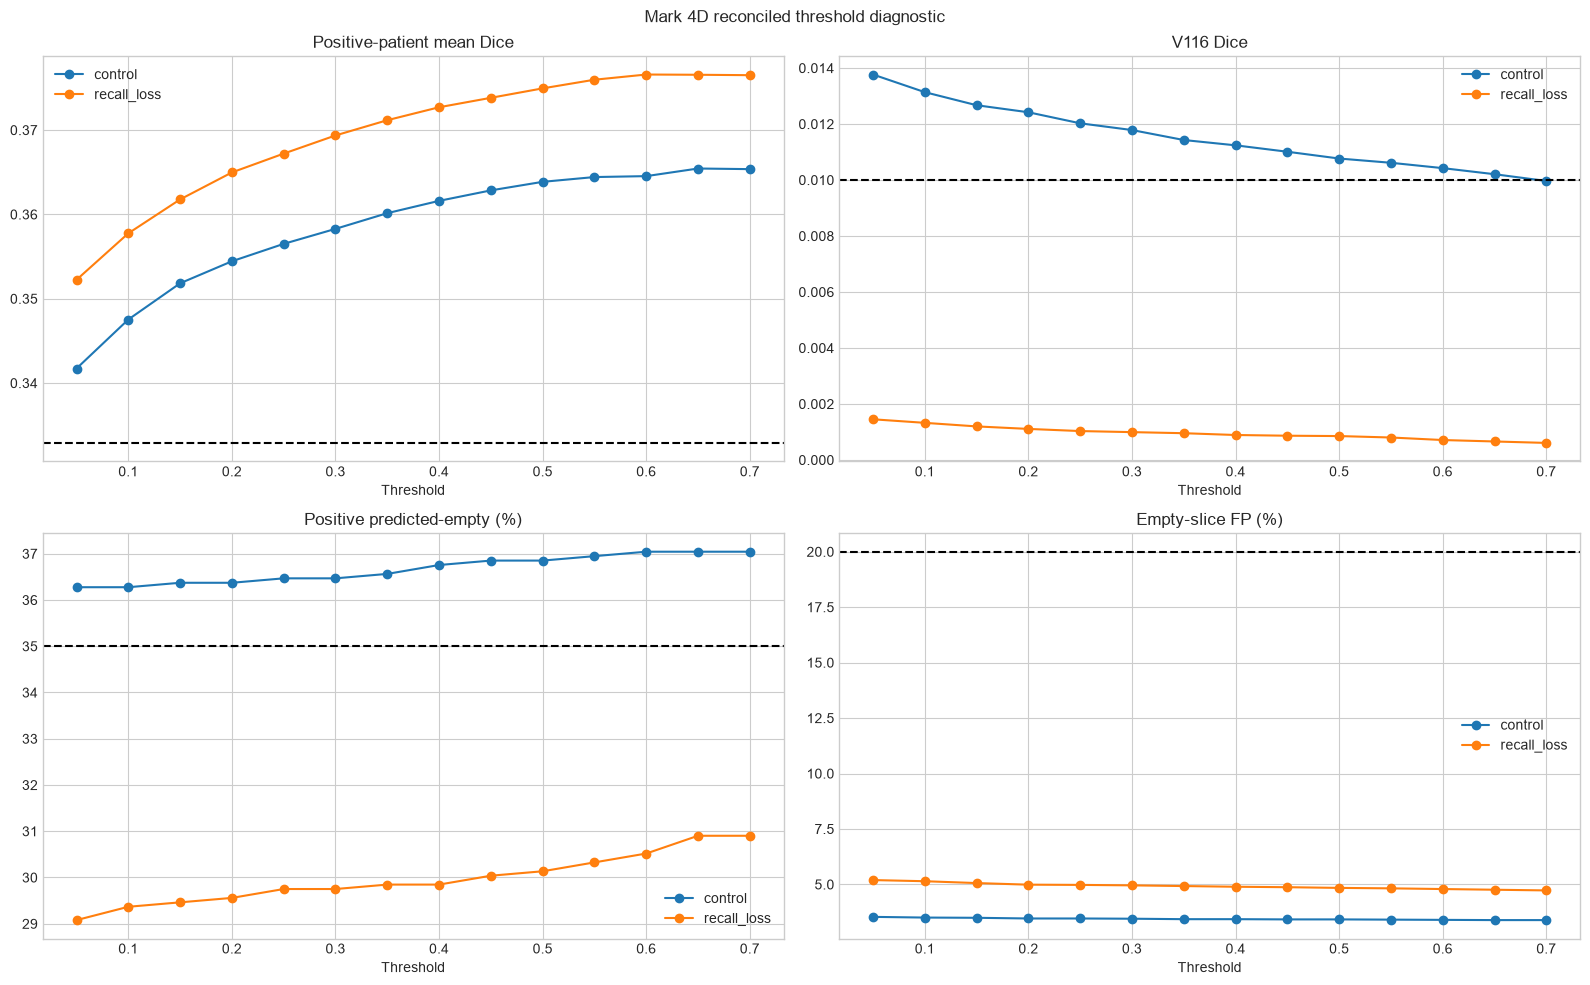

In [6]:
v116=slices.loc[(slices.volume_id==116)&(slices.truth_pixels>0)].copy()
v116['truth_size_quartile']=pd.qcut(v116.truth_pixels,4,labels=['Q1','Q2','Q3','Q4'],duplicates='drop')
v116.to_csv(OUTPUT_DIR/'v116_positive_slice_diagnostic.csv',index=False)
summary=v116.groupby(['model','truth_size_quartile'],observed=True).agg(slices=('sample_id','size'),detected_pct=('detected',lambda x:100*x.mean()),median_truth_probability=('max_truth_probability','median'),median_tumor_pixels=('truth_pixels','median')).reset_index()
summary.to_csv(OUTPUT_DIR/'v116_size_summary.csv',index=False); display(summary)

fig,ax=plt.subplots(2,2,figsize=(16,10))
for name,g in results.groupby('model'):
    ax[0,0].plot(g.threshold,g.mean_patient_dice,marker='o',label=name); ax[0,1].plot(g.threshold,g.volume_116_dice,marker='o',label=name); ax[1,0].plot(g.threshold,g.positive_predicted_empty_pct,marker='o',label=name); ax[1,1].plot(g.threshold,g.empty_slice_false_positive_pct,marker='o',label=name)
ax[0,0].axhline(TARGETS['mean_patient_dice'],ls='--',c='black'); ax[0,0].set_title('Positive-patient mean Dice')
ax[0,1].axhline(TARGETS['volume_116_dice'],ls='--',c='black'); ax[0,1].set_title('V116 Dice')
ax[1,0].axhline(35,ls='--',c='black'); ax[1,0].set_title('Positive predicted-empty (%)')
ax[1,1].axhline(20,ls='--',c='black'); ax[1,1].set_title('Empty-slice FP (%)')
for a in ax.ravel(): a.set_xlabel('Threshold'); a.legend()
fig.suptitle('Mark 4D reconciled threshold diagnostic'); fig.tight_layout(); fig.savefig(OUTPUT_DIR/'reconciled_threshold_dashboard.png',dpi=170,bbox_inches='tight'); plt.show()

### 6. Visualize V116 missed slices and patient-level trade-offs

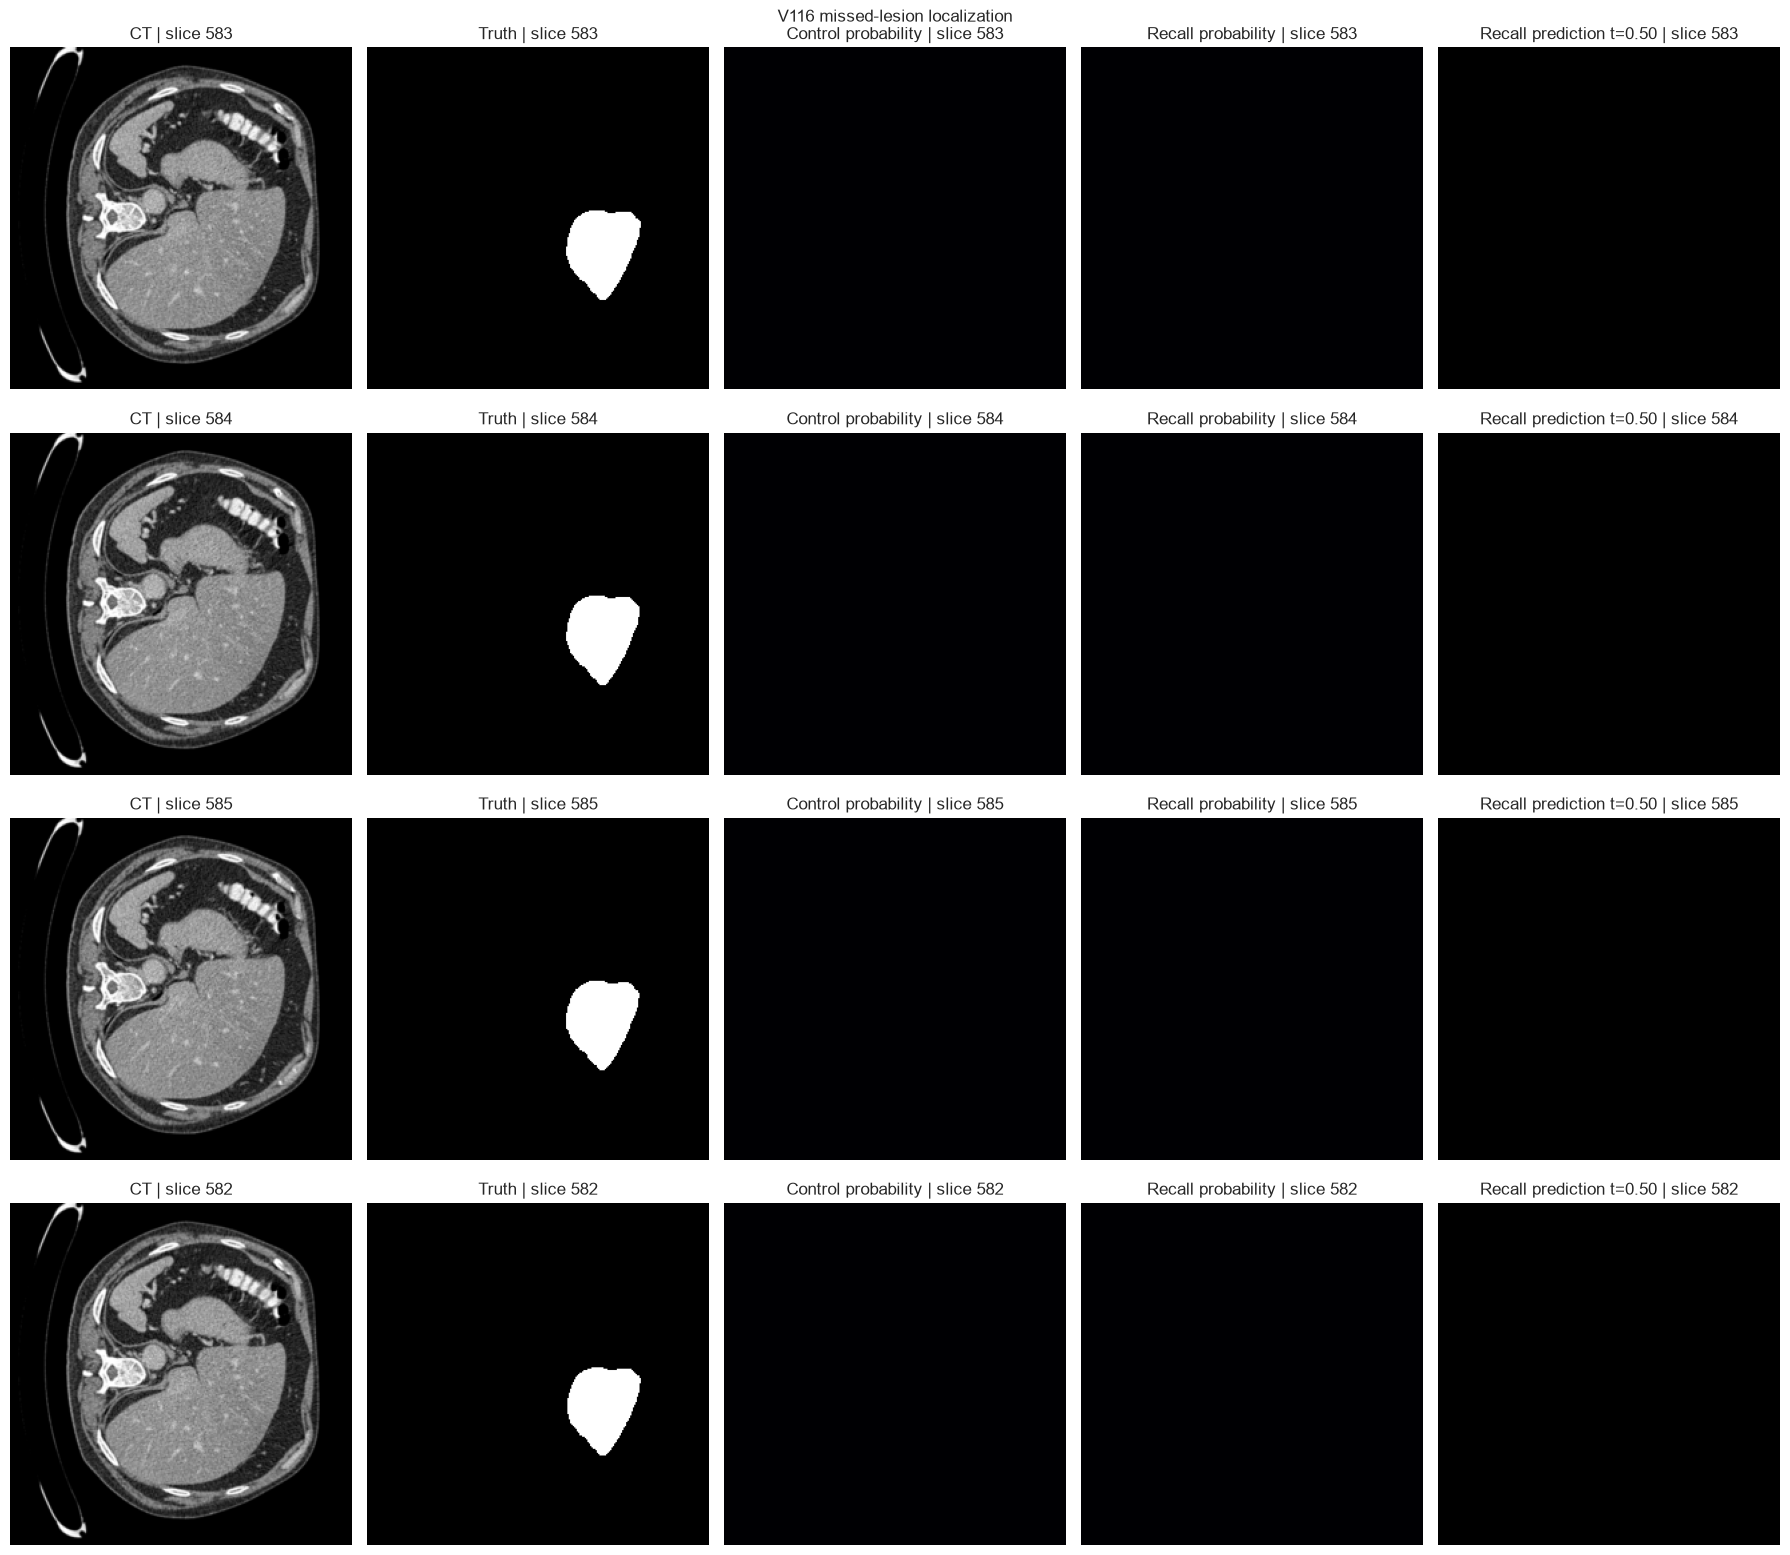

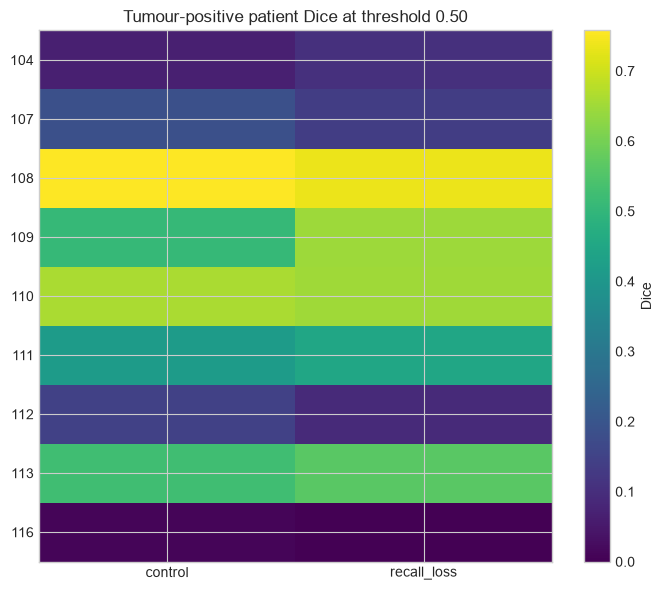

In [7]:
focus=v116.loc[v116.model.eq('recall_loss')].sort_values(['detected','truth_pixels'],ascending=[True,False]).head(4)
fig,axes=plt.subplots(len(focus),5,figsize=(18,4*len(focus)),squeeze=False)
for row_axes,row in zip(axes,focus.itertuples()):
    manifest_row=lookup.loc[row.sample_id]
    with Image.open(DATASET_ROOT/manifest_row.image_path) as h: image=np.asarray(h.convert('L'),np.float32)/255
    control_item=caches['control'][116]; recall_item=caches['recall_loss'][116]; idx=int(np.where(recall_item['slice_index']==row.slice_index)[0][0]); truth=recall_item['truth'][idx].astype(bool); cp=control_item['probability'][idx].astype(float); rp=recall_item['probability'][idx].astype(float)
    panels=[(image,'CT','gray'),(truth,'Truth','gray'),(cp,'Control probability','magma'),(rp,'Recall probability','magma'),(rp>=.5,'Recall prediction t=0.50','gray')]
    for a,(panel,title,cmap) in zip(row_axes,panels): a.imshow(panel,cmap=cmap,vmin=0,vmax=1); a.set_title(f'{title} | slice {row.slice_index}'); a.axis('off')
fig.suptitle('V116 missed-lesion localization'); fig.tight_layout(); fig.savefig(OUTPUT_DIR/'v116_localization_panel.png',dpi=170,bbox_inches='tight'); plt.show()

pivot=patients.loc[patients.threshold.eq(.5)&patients.has_tumor].pivot(index='volume_id',columns='model',values='dice')
fig,ax=plt.subplots(figsize=(7,6)); im=ax.imshow(pivot.values,aspect='auto',cmap='viridis',vmin=0,vmax=max(.7,pivot.max().max())); ax.set_xticks(range(len(pivot.columns)),pivot.columns); ax.set_yticks(range(len(pivot.index)),pivot.index); ax.set_title('Tumour-positive patient Dice at threshold 0.50'); fig.colorbar(im,ax=ax,label='Dice'); fig.tight_layout(); fig.savefig(OUTPUT_DIR/'positive_patient_heatmap.png',dpi=170,bbox_inches='tight'); plt.show()

### 7. Save the corrected gate and next-step decision

In [8]:
eligible=results.loc[results.all_targets_passed]
if not eligible.empty:
    selected=eligible.sort_values('mean_patient_dice',ascending=False).iloc[0]
    decision='FREEZE_CHECKPOINT_AND_THRESHOLD_FOR_BOUNDED_CONTINUATION'; next_notebook='mark_4e_bounded_continuation'
else:
    selected=results.sort_values(['targets_passed','mean_patient_dice'],ascending=False).iloc[0]
    recall_v116=v116.loc[v116.model.eq('recall_loss')]
    median_truth_prob=float(recall_v116.max_truth_probability.median())
    if median_truth_prob>=.20: decision='V116_UNDERCONFIDENT_RUN_MODERATE_ALPHA_OR_THRESHOLD_ABLATION'
    else: decision='V116_LOCALIZATION_FAILURE_RUN_SMALL_LESION_SAMPLING_ABLATION'
    next_notebook='mark_4e_v116_targeted_ablation'

gate={'status':'mark_4d_pass' if not eligible.empty else 'mark_4d_diagnostic_complete_no_full_pass','selected_model':str(selected.model),'selected_threshold':float(selected.threshold),'selected_metrics':{k:float(selected[k]) for k in TARGETS},'targets_passed':int(selected.targets_passed),'decision':decision,'next_notebook':next_notebook,'metric_definition':'mean Dice over nine tumour-positive validation patients','manifest_sha256':EXPECTED_MANIFEST_SHA256,'test_images_accessed':False}
(OUTPUT_DIR/'mark_4d_gate_result.json').write_text(json.dumps(gate,indent=2)); print(json.dumps(gate,indent=2))

{
  "status": "mark_4d_diagnostic_complete_no_full_pass",
  "selected_model": "recall_loss",
  "selected_threshold": 0.6000000238418579,
  "selected_metrics": {
    "mean_patient_dice": 0.3765875940211553,
    "volume_104_dice": 0.10023956287717371,
    "volume_116_dice": 0.0007116977290326623,
    "q1_detected_pct": 47.90874524714829,
    "positive_predicted_empty_pct": 30.518234165067177,
    "empty_slice_false_positive_pct": 4.791040132738774
  },
  "targets_passed": 5,
  "decision": "V116_LOCALIZATION_FAILURE_RUN_SMALL_LESION_SAMPLING_ABLATION",
  "next_notebook": "mark_4e_v116_targeted_ablation",
  "metric_definition": "mean Dice over nine tumour-positive validation patients",
  "manifest_sha256": "575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889",
  "test_images_accessed": false
}


## Takeaways

- Treat `mark_4d_gate_result.json` as the corrected validation decision record.
- If a saved checkpoint and threshold pass all targets, freeze that pair before any bounded continuation.
- If V116 probabilities exist inside the true lesion but remain below threshold, test a moderate recall objective or tightly bounded threshold policy.
- If V116 truth-region probabilities are near zero, thresholding cannot help; use lesion-size-aware sampling or a localization-focused architecture change.
- Do not open the test split until preprocessing, checkpoint, threshold, and inference policy are frozen and the full validation gate passes.